In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import patsy
import geopandas as gpd
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import FuncFormatter
import statsmodels.api as sm
import sys
import os
import itertools
from datetime import datetime, timezone

SCRIPTS_DIR = (Path.cwd() / "scripts" if (Path.cwd() / "scripts").exists() else Path.cwd().parent / "scripts").resolve()
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))
from model_helpers import (
    common_sample_index,
    fit_stats,
    oster_delta,
    pv_kw_per_1000,
    run_ols,
    vif_from_formula,
)

In [2]:
RUN_BOTH_OUTPUT_MODES = True
base = "../outputs/tables/"
base_standardized = "../outputs/standardized_tables/"
MODEL_OUTPUTS_PATH = Path("../data/processed/model_outputs_by_region.csv")

y = "energy_burden_pct"  # change this to one of the outcomes in OUTCOMES_TO_RUN
OUTCOMES_TO_RUN = [
    "y_pv",
    "y_storage",
    "y_chargers",
    "y_wind_mw",
    "any_turbines",
    "y_level1_chargers",
    "y_level2_chargers",
    "y_dc_fast_chargers",
    "energy_burden_pct",
    "log_energy_gap_per_capita",
]


def prep_outcomes_per_capita(df, pop_col="total_population", min_pop=1000):
    """Create per-capita + log1p outcomes; filter tiny-pop ZIPs."""
    df = df.copy()
    df[pop_col] = pd.to_numeric(df[pop_col], errors="coerce")
    der_zero_cols = [
        "PV_system_size_DC",
        "total_chargers",
        "level1_chargers",
        "level2_chargers",
        "dc_fast_chargers",
        "zev_count",
        "plant_capacity_mw",
        "storage_capacity_mw",
        "wind_capacity_mw",
        "wind_turbine_count",
    ]
    for col in der_zero_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df = df[df[pop_col].notna() & (df[pop_col] >= min_pop)].copy()

    pop = df[pop_col].replace(0, np.nan)
    df["level2_chargers_per_1k"] = df["level2_chargers"] * 1000 / pop
    df["y_level2_chargers"] = np.log1p(df["level2_chargers_per_1k"])

    df["level1_chargers_per_1k"] = df["level1_chargers"] * 1000 / pop
    df["y_level1_chargers"] = np.log1p(df["level1_chargers_per_1k"])

    df["dc_fast_chargers_per_1k"] = df["dc_fast_chargers"] * 1000 / pop
    df["y_dc_fast_chargers"] = np.log1p(df["dc_fast_chargers_per_1k"])

    df["chargers_per_1k"] = df["total_chargers"] * 1000 / pop
    df["y_chargers"] = np.log1p(df["chargers_per_1k"])

    df["pv_kw_per_1k"] = pv_kw_per_1000(df["PV_system_size_DC"], pop)
    df["y_pv"] = np.log1p(df["pv_kw_per_1k"])

    df["storage_mw_per_100k"] = df["storage_capacity_mw"] * 100000 / pop
    df["y_storage"] = np.log1p(df["storage_mw_per_100k"])

    df["wind_mw_per_100k"] = df["wind_capacity_mw"] * 100000 / pop
    df["y_wind_mw"] = np.log1p(df["wind_mw_per_100k"])

    # Binary wind outcome. wind_capacity_mw is ~97.5% zeros in the analysis sample, so
    # OLS on log1p of it is a rare-event indicator fit with a linear model. Presence /
    # absence is the honest specification and is what the archived any_turbines tables
    # used (a linear probability model with HC1 errors).
    df["any_turbines"] = (pd.to_numeric(df["wind_turbine_count"], errors="coerce").fillna(0) > 0).astype(float)

    df["plant_mw_per_100k"] = df["plant_capacity_mw"] * 100000 / pop
    df["wind_mw_per_100k_ctrl"] = df["wind_capacity_mw"] * 100000 / pop
    df["turbines_per_100k"] = df["wind_turbine_count"] * 100000 / pop

    df["log_median_household_income"] = np.log(df["median_household_income"].where(df["median_household_income"] > 0))
    df["log_median_housing_value"] = np.log(df["median_housing_value"].where(df["median_housing_value"] > 0))
    df["combined_nonwhite_share"] = df[["pct_black", "pct_hispanic", "pct_asian"]].sum(axis=1, min_count=1)

    df["energy_burden_pct"] = pd.to_numeric(df["energy_burden_pct"], errors="coerce")
    df["energy_gap_per_capita"] = df["energy_affordability_gap"] / pop
    df["log_energy_gap_per_capita"] = np.log1p(df["energy_gap_per_capita"])

    return df


def center_cols(df, cols):
    """Mean-center columns for interaction models."""
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c + "_c"] = df[c] - df[c].mean()
    return df


In [3]:
def clean_region_id(value):
    """
    Keeps ZCTAs/ZIPs as 5-character strings.
    Example: 9001 -> '09001'
    """
    if pd.isna(value):
        return None
    return str(value).split(".")[0].zfill(5)


def model_output_rows_from_result(
    df_used_for_model,
    result,
    outcome,
    model_version,
    assumptions,
    region_id_col="zip_code",
):
    """
    Convert one fitted statsmodels result into wide-format rows
    for the model_outputs SQL table.

    Each row corresponds to:

        one region + one outcome + one model version

    Output columns:
    - region_id
    - outcome_name
    - model_version
    - actual_value
    - predicted_value
    - residual_value
    - residual_percentile
    - priority_flag
    - assumptions
    - generated_at
    """

    required_columns = {region_id_col, outcome}
    missing_columns = required_columns - set(df_used_for_model.columns)

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    generated_at = datetime.now(timezone.utc).isoformat()

    # Statsmodels may drop rows with missing values.
    # This retrieves the exact rows used in the fitted model.
    used_idx = result.model.data.row_labels

    outputs_df = df_used_for_model.loc[used_idx, [region_id_col, outcome]].copy()

    outputs_df[region_id_col] = outputs_df[region_id_col].apply(clean_region_id)
    outputs_df = outputs_df.dropna(subset=[region_id_col])

    outputs_df["actual_value"] = outputs_df[outcome]
    outputs_df["predicted_value"] = result.fittedvalues
    outputs_df["residual_value"] = result.resid

    # Percentile rank of residuals.
    # Low residual percentile = actual is lower than predicted.
    # High residual percentile = actual is higher than predicted.
    outputs_df["residual_percentile"] = outputs_df["residual_value"].rank(pct=True)

    der_outcomes = {
        "y_pv",
        "y_storage",
        "y_chargers",
        "y_level1_chargers",
        "y_level2_chargers",
        "y_dc_fast_chargers",
        "y_wind_mw",
    }

    burden_outcomes = {
        "energy_burden_pct",
        "energy_affordability_index",
        "log_energy_gap_per_capita",
    }

    if outcome in der_outcomes:
        # For DER adoption, low residual = lower adoption than expected.
        cutoff = outputs_df["residual_value"].quantile(0.25)
        outputs_df["priority_flag"] = (
            outputs_df["residual_value"] <= cutoff
        ).astype(int)

    elif outcome in burden_outcomes:
        # For burden outcomes, high residual = higher burden than expected.
        cutoff = outputs_df["residual_value"].quantile(0.75)
        outputs_df["priority_flag"] = (
            outputs_df["residual_value"] >= cutoff
        ).astype(int)

    else:
        # Generic fallback: flag unusually large absolute residuals.
        cutoff = outputs_df["residual_value"].abs().quantile(0.75)
        outputs_df["priority_flag"] = (
            outputs_df["residual_value"].abs() >= cutoff
        ).astype(int)

    rows = []

    for _, row in outputs_df.iterrows():
        rows.append(
            {
                "region_id": row[region_id_col],
                "outcome_name": outcome,
                "model_version": model_version,
                "actual_value": float(row["actual_value"]),
                "predicted_value": float(row["predicted_value"]),
                "residual_value": float(row["residual_value"]),
                "residual_percentile": float(row["residual_percentile"]),
                "priority_flag": int(row["priority_flag"]),
                "assumptions": assumptions,
                "generated_at": generated_at,
            }
        )

    return rows

In [4]:
#### THIS IS JUST FOR CALCULATING DIFFERENT FEATURES
#### ONLY MODIFY TO ADD FEATURES
df = pd.read_csv("../data/processed/combined_der_dataset_w_controls_predictors.csv")
df.drop(columns=['Unnamed: 0'], inplace=True, errors="ignore")
df.rename(columns={"ghi_mean_kwh_m2_day_2024":"ghi_mean_kwh_m2_day_2023",
"wind_ws10m_mean_2024": "wind_ws10m_mean_2023",
    "wind_ws50m_mean_2024": "wind_ws50m_mean_2023"}, inplace=True)
# numeric coercion for key vars (safe)
for c in [
    "median_household_income", "poverty_rate", "pct_bachelors_plus",
    "pct_black", "pct_hispanic", "pct_asian", "median_housing_value",
    "pct_single_family_units", "pct_multifamily_units", "pct_mobile_home_units",
    "pct_other_housing_units", "owner_occupied_rate",
    "cdd65_2023", "hdd65_2023", "t2m_mean_c_2023",
    "ghi_mean_kwh_m2_day_2023", "wind_ws10m_mean_2023", "wind_ws50m_mean_2023",
    "total_population", "lat", "lon", "log_kwh",
    "plant_capacity_mw", "storage_capacity_mw", "wind_capacity_mw", "wind_turbine_count",
    "PV_system_size_DC", "total_chargers", "level1_chargers", "level2_chargers", "dc_fast_chargers",
]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["utility_type"] = df["utility_type"].fillna("POU")
df = prep_outcomes_per_capita(df, min_pop=1000)

core_needed = ["median_household_income", "pct_black", "pct_hispanic", "pct_asian"]
required_housing = [
    "pct_single_family_units", "pct_multifamily_units",
    "pct_mobile_home_units", "pct_other_housing_units", "owner_occupied_rate",
]
missing_housing = [c for c in required_housing if c not in df.columns]
if missing_housing:
    raise ValueError(f"Release dataset is missing housing controls: {missing_housing}")
structure_total = df[[c for c in required_housing if c != "owner_occupied_rate"]].sum(axis=1)
bad_composition = df[required_housing].notna().all(axis=1) & ~np.isclose(structure_total, 1.0, atol=1e-8)
if bad_composition.any():
    raise ValueError(f"Housing structure shares do not sum to one for {bad_composition.sum()} rows.")
df = df.dropna(subset=[c for c in core_needed if c in df.columns]).copy()

<Axes: >

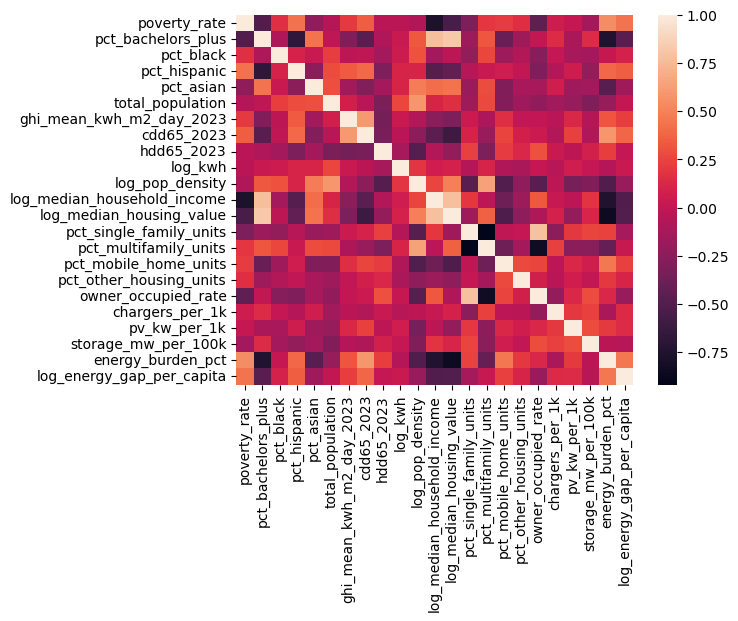

In [5]:
corr = df[[
       'poverty_rate',
       'pct_bachelors_plus', 'pct_black', 'pct_hispanic', 'pct_asian',
       'total_population', 'ghi_mean_kwh_m2_day_2023',
       'cdd65_2023', 'hdd65_2023',
       'log_kwh',
       'log_pop_density',
       'log_median_household_income', 'log_median_housing_value',
       'pct_single_family_units', 'pct_multifamily_units', 'pct_mobile_home_units',
       'pct_other_housing_units', 'owner_occupied_rate',
       'chargers_per_1k', #'y_chargers',
       'pv_kw_per_1k', #'y_pv',
       'storage_mw_per_100k', #'y_storage', 'y_wind_mw',
       "energy_burden_pct",
       "log_energy_gap_per_capita"
       ]].corr()

sns.heatmap(corr)

In [6]:

sys.path.append(str(Path("../scripts").resolve()))
from paper_figure_utils import GRID, MUTED, PAPER_BG, TERM_COLORS, apply_paper_style

OUTPUT_TABLE_DIRS = {
    False: Path("../outputs/tables"),
    True: Path("../outputs/standardized_tables"),
}
GENERATED_FIG_DIR = Path("../outputs/figures/generated")
RUN_MAPS = False
SUPPORTED_NOTEBOOK_OUTCOMES = {"y_pv", "y_storage", "y_chargers", "y_wind_mw", "any_turbines", "y_level1_chargers", "y_level2_chargers", "y_dc_fast_chargers", "energy_burden_pct", "log_energy_gap_per_capita"}
LOWESS_SEED = 42
LOWESS_FRAC = 0.35
LOWESS_BOOTSTRAPS = 300
LOWESS_GRID_SIZE = 200
LOWESS_CI = 95

income = "log_median_household_income"
race = ["pct_black", "pct_hispanic", "pct_asian"]
race_summary = "combined_nonwhite_share"
controls_common = ["poverty_rate"]
controls_3A = ["cdd65_2023", "hdd65_2023"]
controls_3B = ["t2m_mean_c_2023"]
controls_3C = ["ghi_mean_kwh_m2_day_2023"]
controls_3D = ["wind_ws50m_mean_2023"]
ses_bach = ["pct_bachelors_plus"]
ses_house = ["log_median_housing_value"]
# The four exhaustive B25024 housing-structure shares sum to one. Omit single-family
# and include multifamily, mobile-home, and boat/RV/van/other shares so every reported
# structure coefficient is an interpretable contrast with a true single-family base.
HOUSING_STRUCTURE_REFERENCE = "pct_single_family_units"
housing_structure = [
    "pct_multifamily_units",
    "pct_mobile_home_units",
    "pct_other_housing_units",
]
# B25003 tenure. Owner share only - owner and renter sum to 1, so renters are the
# omitted reference. Kept as its own control set so Model 2D can show what tenure adds
# beyond building type: single-family share explains only ~62% of tenure variation.
tenure = ["owner_occupied_rate"]
utility_fe = "C(utility)"
cluster_utility = "utility"
# county_geoid round-trips through CSV as a float (NaN forces float64), so a bare
# astype(str) yields "6037.0" and turns missing counties back into a "nan" level that
# behaves like a real county in C(county_geoid) and in county-clustered SEs. Restore
# the zero-padded FIPS string and keep missing as genuine NA.
def _fips5(value):
    """county_geoid round-trips through CSV as a float (NaN forces float64), so a bare
    astype(str) yields "6037.0" and turns missing counties into a "nan" level that acts
    like a real county in C(county_geoid) and in county-clustered SEs."""
    if pd.isna(value):
        return pd.NA
    return str(int(float(value))).zfill(5)


county_values = df["county_geoid"].map(_fips5)
# Patsy cannot sort pandas StringDtype levels containing pd.NA. Use ordinary
# objects with np.nan so C(county_geoid) drops missing rows correctly.
df["county_geoid"] = county_values.astype(object).where(county_values.notna(), np.nan)
county_fe = "C(county_geoid)"
latlon = ["lat", "lon"]
demand_proxy = "log_kwh"
energy_burden_features = ["energy_burden_pct", "log_energy_gap_per_capita"]

# Block registry for the genuinely nested cumulative ladder (Models C1-C5/S/O; see
# REGRESSION_ROBUSTNESS_PLAN.md). CONFOUNDER_BLOCKS holds pre-treatment / non-mediating
# controls only. log_kwh (demand) and the infrastructure-capacity variables sit on the
# causal path from income/race to DER adoption, so they are never part of the saturated
# confounders-only model; they live in MEDIATOR_BLOCKS instead and only enter Model O,
# an explicitly over-controlled lower bound. MEDIATOR_BLOCKS is built per-outcome (the
# infrastructure block excludes outcome-specific leakage columns) inside
# run_outcome_suite, alongside the existing Model 7 infra construction it reuses.
CONFOUNDER_BLOCKS = {
    "education": ses_bach,
    "housing_value": ses_house,
    "housing_structure": housing_structure,
    "tenure": tenure,
    "utility_fe": [utility_fe],
    "county_fe": [county_fe],
}
SPEC_CURVE_FOCAL_TERMS = [income, "pct_black", "pct_hispanic", "pct_asian"]

term_labels = {
    "cdd65_2023": "Cooling degree days",
    "hdd65_2023": "Heating degree days",
    "ghi_mean_kwh_m2_day_2023": "Solar irradiance (GHI)",
    "wind_ws10m_mean_2023": "Wind speed (10m)",
    "wind_ws50m_mean_2023": "Wind speed (50m)",
    "poverty_rate": "Poverty rate",
    "pct_bachelors_plus": "% Bachelor's+",
    "pct_black": "% Black",
    "pct_hispanic": "% Hispanic",
    "pct_asian": "% Asian",
    "pct_single_family_units": "% single-family units",
    "pct_multifamily_units": "% multifamily units",
    "pct_mobile_home_units": "% mobile-home units",
    "pct_other_housing_units": "% boat/RV/van/other units",
    "combined_nonwhite_share": "Combined non-white share",
    "log_median_household_income": "Log median household income",
    "log_median_housing_value": "Log median housing value",
    "log_pop_density": "Log population density",
    "log_kwh": "Log annual electricity demand",
    "energy_burden_pct": "Energy burden",
    "energy_affordability_index": "Energy affordability index",
    "log_energy_gap_per_capita": "Log energy affordability gap per capita",
    "y_pv": "Solar PV adoption",
    "y_chargers": "EV charger availability",
    "y_level1_chargers": "Level 1 charger availability",
    "y_level2_chargers": "Level 2 charger availability",
    "y_dc_fast_chargers": "DC fast charger availability",
    "y_storage": "Storage deployment",
    "y_wind_mw": "Wind capacity",
    "any_turbines": "Any turbines (presence)",
    "owner_occupied_rate": "% owner-occupied",
}

analysis_df_raw = df.copy()


In [7]:
def build_formula(outcome, climate_controls, extra_terms=None, fe_terms=None,
                  keepincome=True, demand_proxy_term=None, controls_common_terms=None):
    rhs = []
    if keepincome:
        rhs.append(income)
    rhs += race
    rhs += list(controls_common_terms or controls_common)
    if demand_proxy_term is not None:
        rhs.append(demand_proxy_term)
    rhs += list(climate_controls or [])
    if extra_terms:
        rhs += list(extra_terms)
    if fe_terms:
        rhs += list(fe_terms)
    seen = set()
    rhs = [x for x in rhs if not (x in seen or seen.add(x))]
    return f"{outcome} ~ " + " + ".join(rhs)


def controls_for_outcome(outcome):
    if outcome == "y_pv":
        return controls_3C
    if outcome == "y_storage":
        return controls_3A
    if outcome in {"y_chargers", "y_level1_chargers", "y_level2_chargers", "y_dc_fast_chargers"}:
        return controls_3A
    if outcome in {"y_wind_mw", "any_turbines"}:
        return controls_3D
    if outcome in energy_burden_features:
        return controls_3A + controls_3C
    return []


def standardize_model_frame(source_df, outcome):
    df_model = source_df.copy()
    candidate_standardized_predictors = [
        "log_median_household_income",
        "log_median_housing_value",
        "log_pop_density",
        "poverty_rate",
        "pct_bachelors_plus",
        "pct_black",
        "pct_hispanic",
        "pct_asian",
        "combined_nonwhite_share",
        "pct_single_family_units",
        "pct_multifamily_units",
        "pct_mobile_home_units",
        "pct_other_housing_units",
        "owner_occupied_rate",
        "cdd65_2023",
        "hdd65_2023",
        "t2m_mean_c_2023",
        "ghi_mean_kwh_m2_day_2023",
        "wind_ws10m_mean_2023",
        "wind_ws50m_mean_2023",
        "lat",
        "lon",
        "log_kwh",
        "plant_capacity_mw",
        "storage_capacity_mw",
        "wind_capacity_mw",
        "wind_turbine_count",
        "PV_system_size_DC",
        "plant_mw_per_100k",
        "storage_mw_per_100k",
        "wind_mw_per_100k_ctrl",
        "turbines_per_100k",
        "energy_burden_pct",
        "energy_affordability_index",
        "log_energy_gap_per_capita",
        "y_pv",
        "y_storage",
        "y_chargers",
        "y_wind_mw",
        "y_level1_chargers",
        "y_level2_chargers",
        "y_dc_fast_chargers",
    ]
    cols_to_standardize = [
        c for c in candidate_standardized_predictors
        if c in df_model.columns and c != outcome and df_model[c].nunique(dropna=True) > 1
    ]
    if cols_to_standardize:
        df_model[cols_to_standardize] = StandardScaler().fit_transform(df_model[cols_to_standardize])
    return df_model


def export_result_table(res, title, table_dir):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(res.summary().tables[0])
    print(res.summary().tables[1])
    table_dir.mkdir(parents=True, exist_ok=True)
    res.summary2().tables[1].to_csv(table_dir / f"{title}.csv")
    # Companion file, not trailing rows in the coefficient table: paper_figure_utils
    # .load_all_coefs() globs every CSV in table_dir and expects one row per term.
    # A same-named-with-suffix file (mirroring the existing "... VIF.csv" convention)
    # keeps N/R^2 alongside the coefficients without polluting that parse. It is
    # already excluded automatically the same way VIF files are: load_coef_csv raises
    # KeyError on its columns and load_all_coefs catches and skips silently.
    stats = fit_stats(res)
    pd.DataFrame([stats]).to_csv(table_dir / f"{title} fit stats.csv", index=False)


def export_vif_table(formula, df_model, title, table_dir):
    vif = vif_from_formula(formula, df_model)
    print(vif.head(30))
    vif.to_csv(table_dir / f"{title} VIF.csv", index=False)
    return vif


def run_outcome_suite(outcome, source_df, standardized_flag):
    table_dir = OUTPUT_TABLE_DIRS[standardized_flag]
    mode_label = "standardized" if standardized_flag else "raw"
    controls_cur = controls_for_outcome(outcome)
    df_model = standardize_model_frame(source_df, outcome) if standardized_flag else source_df.copy()
    model_outputs_rows = []

    def store_result(
        label,
        res,
        df_used_for_model=None,
        save_model_outputs=True,
        assumptions=None,
    ):
        export_result_table(res, f"{outcome} | {label}", table_dir)

        if save_model_outputs:
            if df_used_for_model is None:
                df_used_for_model = df_model

            model_version = f"{outcome} | {label} | {mode_label}"

            if assumptions is None:
                assumptions_text = f"{mode_label} OLS model for {outcome}: {label}."
            else:
                assumptions_text = assumptions

            model_outputs_rows.extend(
                model_output_rows_from_result(
                    df_used_for_model=df_used_for_model,
                    result=res,
                    outcome=outcome,
                    model_version=model_version,
                    assumptions=assumptions_text,
                    region_id_col="zip_code",
                )
            )
        return res

    f1 = build_formula(outcome, climate_controls=controls_cur, controls_common_terms=["poverty_rate"])
    res1 = store_result("Model 1 baseline (climate controls)", run_ols(f1, df_model))
    export_vif_table(f1, df_model, f"{outcome} | Model 1 baseline (climate controls)", table_dir)

    f2a = build_formula(outcome, climate_controls=controls_cur, extra_terms=ses_bach, keepincome=True, controls_common_terms=["poverty_rate"])
    res2a = store_result("Model 2 (add bachelors)", run_ols(f2a, df_model))
    export_vif_table(f2a, df_model, f"{outcome} | Model 2 (add bachelors)", table_dir)

    f2b = build_formula(outcome, climate_controls=controls_cur, extra_terms=ses_house, keepincome=True, controls_common_terms=["poverty_rate"])
    res2b = store_result("Model 2 (add housing value)", run_ols(f2b, df_model))
    export_vif_table(f2b, df_model, f"{outcome} | Model 2 (add housing value)", table_dir)

    missing_or_constant_housing = [
        c for c in housing_structure
        if c not in df_model.columns or df_model[c].nunique(dropna=True) <= 1
    ]
    if missing_or_constant_housing:
        raise ValueError(
            "Model 2C requires every non-reference housing category; missing or "
            f"constant: {missing_or_constant_housing}"
        )
    available_housing_structure = housing_structure
    f2c = build_formula(outcome, climate_controls=controls_cur, extra_terms=available_housing_structure, keepincome=True, controls_common_terms=["poverty_rate"])
    res2c = store_result("Model 2C (add housing structure)", run_ols(f2c, df_model))
    export_vif_table(f2c, df_model, f"{outcome} | Model 2C (add housing structure)", table_dir)

    missing_or_constant_tenure = [
        c for c in tenure
        if c not in df_model.columns or df_model[c].nunique(dropna=True) <= 1
    ]
    if missing_or_constant_tenure:
        raise ValueError(
            "Model 2D requires the tenure control; missing or constant: "
            f"{missing_or_constant_tenure}"
        )
    available_tenure = tenure
    f2d = build_formula(
        outcome, climate_controls=controls_cur,
        extra_terms=available_housing_structure + available_tenure,
        keepincome=True, controls_common_terms=["poverty_rate"],
    )
    res2d = store_result("Model 2D (add housing structure and tenure)", run_ols(f2d, df_model))
    export_vif_table(f2d, df_model, f"{outcome} | Model 2D (add housing structure and tenure)", table_dir)

    f3a = build_formula(outcome, climate_controls=controls_3A)
    res3a = store_result("Model 3A (HDD + CDD)", run_ols(f3a, df_model))
    export_vif_table(f3a, df_model, f"{outcome} | Model 3A (HDD + CDD)", table_dir)

    f3b = build_formula(outcome, climate_controls=controls_3B)
    res3b = store_result("Model 3B (temp only)", run_ols(f3b, df_model))
    export_vif_table(f3b, df_model, f"{outcome} | Model 3B (temp only)", table_dir)

    f3c = build_formula(outcome, climate_controls=controls_3C)
    res3c = store_result("Model 3C (GHI only)", run_ols(f3c, df_model))
    export_vif_table(f3c, df_model, f"{outcome} | Model 3C (GHI only)", table_dir)

    df_int = center_cols(df_model, [income] + race)
    f4 = (
        f"{outcome} ~ log_median_household_income_c + pct_black_c + pct_hispanic_c + pct_asian_c"
        + (" + " + " + ".join(["poverty_rate"] + list(controls_cur)) if controls_cur else " + poverty_rate")
        + " + log_median_household_income_c:pct_black_c"
        + " + log_median_household_income_c:pct_hispanic_c"
        + " + log_median_household_income_c:pct_asian_c"
    )
    res4 = store_result("Model 4 interactions (centered)", run_ols(f4, df_int))
    export_vif_table(f4, df_int, f"{outcome} | Model 4 interactions (centered)", table_dir)

    # Model 4R is the RESTRICTED counterpart to Model 4: it drops poverty_rate, which
    # overlaps heavily with log median household income, and asks whether the
    # income-by-race interactions survive without that collinear control. Previously
    # 4R spelled the same control set as Model 4 via controls_common, so the two
    # models were byte-identical and the ladder carried a duplicated rung.
    f4r = (
        f"{outcome} ~ log_median_household_income_c + pct_black_c + pct_hispanic_c + pct_asian_c"
        + (" + " + " + ".join(list(controls_cur)) if controls_cur else "")
        + " + log_median_household_income_c:pct_black_c"
        + " + log_median_household_income_c:pct_hispanic_c"
        + " + log_median_household_income_c:pct_asian_c"
    )
    res4r = store_result("Model 4R interactions (centered, no poverty control)", run_ols(f4r, df_int))
    export_vif_table(f4r, df_int, f"{outcome} | Model 4R interactions (centered, no poverty control)", table_dir)

    f5 = build_formula(outcome, climate_controls=controls_cur, fe_terms=[utility_fe])
    res5 = store_result("Model 5 utility FE", run_ols(f5, df_model))
    export_vif_table(f5, df_model, f"{outcome} | Model 5 utility FE", table_dir)
    res5c = store_result("Model 5C clustered SEs by county", run_ols(f5, df_model, cluster_col="county_geoid"))

    f6a = build_formula(outcome, climate_controls=[], extra_terms=latlon)
    res6a = store_result("Model 6A lat and lon", run_ols(f6a, df_model))
    export_vif_table(f6a, df_model, f"{outcome} | Model 6A lat and lon", table_dir)

    f6b = build_formula(outcome, climate_controls=[], extra_terms=[county_fe])
    res6b = store_result("Model 6B county fe", run_ols(f6b, df_model))
    export_vif_table(f6b, df_model, f"{outcome} | Model 6B county fe", table_dir)
    res6_cluster = store_result("No County FE + clustered SEs (county)", run_ols(f1, df_model, cluster_col="county_geoid"))

    charger_exclusions = [
        "total_chargers",
        "level1_chargers",
        "level2_chargers",
        "dc_fast_chargers",
        "chargers_per_1k",
        "level1_chargers_per_1k",
        "level2_chargers_per_1k",
        "dc_fast_chargers_per_1k",
        "y_chargers",
        "y_level1_chargers",
        "y_level2_chargers",
        "y_dc_fast_chargers",
    ]
    exclude_for_y = {
        "y_chargers": charger_exclusions,
        "y_level1_chargers": charger_exclusions,
        "y_level2_chargers": charger_exclusions,
        "y_dc_fast_chargers": charger_exclusions,
        "y_pv": ["PV_system_size_DC", "pv_kw_per_1k", "y_pv"],
        "y_storage": ["storage_capacity_mw", "storage_mw_per_100k"],
        "y_wind_mw": ["wind_capacity_mw", "wind_mw_per_100k"],
        "any_turbines": ["wind_capacity_mw", "wind_mw_per_100k", "wind_turbine_count", "wind_mw_per_100k_ctrl", "turbines_per_100k", "any_turbines"],
    }
    infra_candidates = ["plant_capacity_mw", "storage_capacity_mw", "wind_capacity_mw", "wind_turbine_count", "PV_system_size_DC"]
    infra = [c for c in infra_candidates if c in df_model.columns and c not in exclude_for_y.get(outcome, [])]
    f7 = build_formula(outcome, climate_controls=controls_cur, extra_terms=infra)
    res7 = store_result("Model 7 (infrastructure controls, outcome-safe)", run_ols(f7, df_model))
    export_vif_table(f7, df_model, f"{outcome} | Model 7 (infrastructure controls, outcome-safe)", table_dir)

    infra_pc = [c for c in ["plant_mw_per_100k", "storage_mw_per_100k", "wind_mw_per_100k_ctrl", "turbines_per_100k"] if c in df_model.columns]
    infra_pc = [c for c in infra_pc if c not in exclude_for_y.get(outcome, [])]
    f7pc = build_formula(outcome, climate_controls=controls_cur, extra_terms=infra_pc)
    res7pc = store_result("Model 7 (per-capita infrastructure controls)", run_ols(f7pc, df_model))
    export_vif_table(f7pc, df_model, f"{outcome} | Model 7 (per-capita infrastructure controls)", table_dir)

    f8 = build_formula(outcome, climate_controls=controls_cur, extra_terms=[demand_proxy])
    res8 = store_result("Model 8 add demand proxy", run_ols(f8, df_model))
    export_vif_table(f8, df_model, f"{outcome} | Model 8 add demand proxy", table_dir)

    if outcome in energy_burden_features:
        # Model 9A (predicting burden): flips the direction of the analysis and asks
        # whether DER access predicts affordability outcomes. Restored from an earlier
        # notebook version - the figure that consumes it (energy_burden_der_m9.png) had
        # been drawing on an orphaned table no code produced.
        #
        # log_median_household_income is deliberately EXCLUDED. Energy burden is
        # conventionally energy cost divided by household income, so income sits in the
        # outcome's denominator; regressing burden on income is substantially mechanical
        # (income alone explains R^2 = 0.556). See AUDIT.md. poverty_rate is dropped for
        # the same reason. Terms match the archived specification exactly.
        m9_burden_terms = ["y_pv", "y_storage", "y_chargers"]
        f9b = f"{outcome} ~ " + " + ".join(
            race + [demand_proxy] + list(controls_cur) + m9_burden_terms
        )
        res9b = store_result("Model 9A (predicting burden)", run_ols(f9b, df_model))
        export_vif_table(f9b, df_model, f"{outcome} | Model 9A (predicting burden)", table_dir)

    if outcome == "y_storage":
        model9_terms = ["pct_bachelors_plus", "plant_mw_per_100k", "wind_mw_per_100k_ctrl", "y_pv"]
        f9 = build_formula(
            outcome,
            climate_controls=controls_cur,
            extra_terms=model9_terms,
            keepincome=True,
            demand_proxy_term=demand_proxy,
            controls_common_terms=["poverty_rate"],
        )
        res9 = store_result("Model 9 + pv control (most controlled)", run_ols(f9, df_model))
        export_vif_table(f9, df_model, f"{outcome} | Model 9 + pv control (most controlled)", table_dir)

    # --- Genuinely nested cumulative ladder: Models C1-C5, S (saturated confounders),
    # O (over-controlled lower bound). Unlike M1-M9 above (a one-block-at-a-time
    # sensitivity fan - siblings, not rungs), each Cn formula here is a strict RHS
    # superset of C(n-1), and all seven fit on one frozen common sample so coefficient
    # movement reflects added controls rather than sample composition. See
    # REGRESSION_ROBUSTNESS_PLAN.md Sec. 2-3 for the design rationale.
    edu_house = CONFOUNDER_BLOCKS["education"] + CONFOUNDER_BLOCKS["housing_value"]
    structure_tenure = CONFOUNDER_BLOCKS["housing_structure"] + CONFOUNDER_BLOCKS["tenure"]

    fC1 = build_formula(outcome, climate_controls=controls_cur, controls_common_terms=["poverty_rate"])
    fC2 = build_formula(outcome, climate_controls=controls_cur, extra_terms=edu_house, controls_common_terms=["poverty_rate"])
    fC3 = build_formula(outcome, climate_controls=controls_cur, extra_terms=edu_house + structure_tenure, controls_common_terms=["poverty_rate"])
    fC4 = build_formula(outcome, climate_controls=controls_cur, extra_terms=edu_house + structure_tenure, fe_terms=[utility_fe], controls_common_terms=["poverty_rate"])
    # C5: county FE replaces climate rather than stacking with it (climate is nearly
    # collinear with 58-county FE at ZIP granularity).
    fC5 = build_formula(outcome, climate_controls=[], extra_terms=edu_house + structure_tenure, fe_terms=[utility_fe, county_fe], controls_common_terms=["poverty_rate"])
    fS = fC5

    mediator_blocks_cur = {"demand": [demand_proxy], "infrastructure": infra}
    mediators = mediator_blocks_cur["demand"] + mediator_blocks_cur["infrastructure"]
    fO = build_formula(outcome, climate_controls=[], extra_terms=edu_house + structure_tenure + mediators, fe_terms=[utility_fe, county_fe], controls_common_terms=["poverty_rate"])

    ladder_formulas = [fC1, fC2, fC3, fC4, fC5, fO]
    ladder_sample = common_sample_index(
        ladder_formulas, df_model, cluster_col="county_geoid",
    )
    df_ladder = df_model.loc[ladder_sample]

    resC1 = store_result("Model C1 (core, common sample)", run_ols(fC1, df_ladder), df_used_for_model=df_ladder)
    export_vif_table(fC1, df_ladder, f"{outcome} | Model C1 (core, common sample)", table_dir)

    resC2 = store_result("Model C2 (+ education, housing value)", run_ols(fC2, df_ladder), df_used_for_model=df_ladder)
    export_vif_table(fC2, df_ladder, f"{outcome} | Model C2 (+ education, housing value)", table_dir)

    resC3 = store_result("Model C3 (+ housing structure, tenure)", run_ols(fC3, df_ladder), df_used_for_model=df_ladder)
    export_vif_table(fC3, df_ladder, f"{outcome} | Model C3 (+ housing structure, tenure)", table_dir)

    resC4 = store_result("Model C4 (+ utility FE)", run_ols(fC4, df_ladder), df_used_for_model=df_ladder)
    export_vif_table(fC4, df_ladder, f"{outcome} | Model C4 (+ utility FE)", table_dir)

    resC5 = store_result(
        "Model C5 (+ county FE, county-clustered SEs)",
        run_ols(fC5, df_ladder, cluster_col="county_geoid"),
        df_used_for_model=df_ladder,
    )
    export_vif_table(fC5, df_ladder, f"{outcome} | Model C5 (+ county FE, county-clustered SEs)", table_dir)

    resS = store_result(
        "Model S (saturated confounders)",
        run_ols(fS, df_ladder, cluster_col="county_geoid"),
        df_used_for_model=df_ladder,
        save_model_outputs=False,
    )
    export_vif_table(fS, df_ladder, f"{outcome} | Model S (saturated confounders)", table_dir)

    resO = store_result(
        "Model O (over-controlled: + demand and infrastructure)",
        run_ols(fO, df_ladder, cluster_col="county_geoid"),
        df_used_for_model=df_ladder,
    )
    export_vif_table(fO, df_ladder, f"{outcome} | Model O (over-controlled: + demand and infrastructure)", table_dir)

    for label, res in [
        ("Model C1 (core, common sample)", resC1),
        ("Model C2 (+ education, housing value)", resC2),
        ("Model C3 (+ housing structure, tenure)", resC3),
        ("Model C4 (+ utility FE)", resC4),
        ("Model C5 (+ county FE, county-clustered SEs)", resC5),
        ("Model S (saturated confounders)", resS),
        ("Model O (over-controlled: + demand and infrastructure)", resO),
    ]:
        assert res.nobs == len(ladder_sample), (
            f"{outcome} | {label}: nobs {res.nobs} != frozen sample {len(ladder_sample)}. "
            "Every cumulative rung must share the same sample; see common_sample_index."
        )

    # Oster (2019) delta: how much selection on unobservables (relative to the observed
    # confounders) would be needed to drive each focal coefficient to zero, comparing
    # the unadjusted core (C1) to the saturated confounders-only model (S). Computed
    # only for the raw (non-standardized) pass: delta is a ratio of beta_full to
    # (beta_restricted - beta_full), so it is invariant to standardizing that one term
    # and recomputing it per mode would just add noise-level duplicate rows.
    oster_rows = []
    if not standardized_flag:
        for term in SPEC_CURVE_FOCAL_TERMS:
            if term not in resC1.params.index or term not in resS.params.index:
                continue
            delta = oster_delta(resC1, resS, term)
            oster_rows.append({
                "outcome": outcome,
                "term": term,
                "beta_restricted": resC1.params[term],
                "beta_full": resS.params[term],
                "r2_restricted": resC1.rsquared,
                "r2_full": resS.rsquared,
                "rmax": min(1.3 * resS.rsquared, 1.0),
                "delta": delta,
            })

    # Plot generation lives in plotting_outcomes.ipynb so regression reruns only export model outputs.

    print(f"Completed {outcome} ({mode_label})")
    return {
        "outcome": outcome,
        "mode": mode_label,
        "model_outputs_rows": model_outputs_rows,
        "oster_rows": oster_rows,
        "ladder_sample_size": len(ladder_sample),
    }


In [8]:
all_model_outputs_rows = []
all_oster_rows = []

for y in OUTCOMES_TO_RUN:
    result_dict = run_outcome_suite(y, analysis_df_raw, False)
    model_outputs_rows = result_dict.pop("model_outputs_rows", [])
    all_model_outputs_rows.extend(model_outputs_rows)
    all_oster_rows.extend(result_dict.pop("oster_rows", []))

if RUN_BOTH_OUTPUT_MODES:
    for y in OUTCOMES_TO_RUN:
        run_outcome_suite(y, analysis_df_raw, True)

model_outputs_df = pd.DataFrame(all_model_outputs_rows)
MODEL_OUTPUTS_PATH.parent.mkdir(parents=True, exist_ok=True)
model_outputs_df.to_csv(MODEL_OUTPUTS_PATH, index=False)

print(f"Saved model outputs to {MODEL_OUTPUTS_PATH}")
display(model_outputs_df.head())
display(model_outputs_df["model_version"].value_counts())

oster_df = pd.DataFrame(all_oster_rows)
OSTER_DELTA_PATH = Path("../outputs/tables/oster_delta.csv")
OSTER_DELTA_PATH.parent.mkdir(parents=True, exist_ok=True)
oster_df.to_csv(OSTER_DELTA_PATH, index=False)
print(f"Saved Oster delta bounds to {OSTER_DELTA_PATH}")
display(oster_df)


y_pv | Model 1 baseline (climate controls)
                            OLS Regression Results                            
Dep. Variable:                   y_pv   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     21.47
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           3.20e-24
Time:                        15:58:43   Log-Likelihood:                -2798.1
No. Observations:                1390   AIC:                             5610.
Df Residuals:                    1383   BIC:                             5647.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

                       feature       VIF
0  log_median_household_income  3.420314
1                 poverty_rate  2.758622
2        pct_mobile_home_units  1.542138
3                 pct_hispanic  1.467810
4        pct_multifamily_units  1.450731
5                    pct_asian  1.367368
6     ghi_mean_kwh_m2_day_2023  1.168845
7                    pct_black  1.125531
8      pct_other_housing_units  1.112733
y_pv | Model 2D (add housing structure and tenure)
                            OLS Regression Results                            
Dep. Variable:                   y_pv   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     23.06
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           2.12e-40
Time:                        15:58:43   Log-Likelihood:                -2755.7
No. Observations:                1390   AIC:                     

                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -8.5978      2.637     -3.260      0.001     -13.767      -3.428
log_median_household_income     1.0903      0.209      5.224      0.000       0.681       1.499
pct_black                      -3.4121      0.735     -4.640      0.000      -4.854      -1.971
pct_hispanic                    0.9148      0.245      3.733      0.000       0.435       1.395
pct_asian                      -2.1029      0.308     -6.838      0.000      -2.706      -1.500
poverty_rate                   -0.5790      1.089     -0.532      0.595      -2.713       1.555
ghi_mean_kwh_m2_day_2023        0.3410      0.142      2.395      0.017       0.062       0.620
                       feature       VIF
0  log_median_household_income  3.094116
1                 poverty_rate  2.590290
2            

                       feature       VIF
0  log_median_household_income  2.999421
1                 poverty_rate  2.449579
2                 pct_hispanic  1.406823
3                    pct_asian  1.267540
4     ghi_mean_kwh_m2_day_2023  1.125732
5                    pct_black  1.036506
y_pv | Model 5C clustered SEs by county
                            OLS Regression Results                            
Dep. Variable:                   y_pv   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     24.42
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           2.80e-13
Time:                        15:58:44   Log-Likelihood:                -2427.8
No. Observations:                1257   AIC:                             4874.
Df Residuals:                    1248   BIC:                             4920.
Df Model:                           8    

                       feature       VIF
0  log_median_household_income  3.082159
1                 poverty_rate  2.590032
2                 pct_hispanic  1.329429
3                    pct_asian  1.255042
4                    pct_black  1.037857
y_pv | No County FE + clustered SEs (county)
                            OLS Regression Results                            
Dep. Variable:                   y_pv   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     7.374
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           1.46e-05
Time:                        15:58:44   Log-Likelihood:                -2734.8
No. Observations:                1362   AIC:                             5484.
Df Residuals:                    1355   BIC:                             5520.
Df Model:                           6                                        

...

Saved model outputs to ../data/processed/model_outputs_by_region.csv


,region_id,outcome_name,model_version,actual_value,predicted_value,residual_value,residual_percentile,priority_flag,assumptions,generated_at
0,90001,y_pv,y_pv | Model 1 baseline (climate controls) | raw,4.149507,5.538366,-1.388859,0.146763,1,raw OLS model for y_pv: Model 1 baseline (clim...,2026-08-19T22:58:43.674178+00:00
1,90002,y_pv,y_pv | Model 1 baseline (climate controls) | raw,3.687960,5.054787,-1.366827,0.148921,1,raw OLS model for y_pv: Model 1 baseline (clim...,2026-08-19T22:58:43.674178+00:00
2,90003,y_pv,y_pv | Model 1 baseline (climate controls) | raw,2.719707,4.979353,-2.259646,0.097842,1,raw OLS model for y_pv: Model 1 baseline (clim...,2026-08-19T22:58:43.674178+00:00
3,90004,y_pv,y_pv | Model 1 baseline (climate controls) | raw,3.348634,4.902722,-1.554088,0.128058,1,raw OLS model for y_pv: Model 1 baseline (clim...,2026-08-19T22:58:43.674178+00:00
4,90005,y_pv,y_pv | Model 1 baseline (climate controls) | raw,3.192294,4.509754,-1.317461,0.155396,1,raw OLS model for y_pv: Model 1 baseline (clim...,2026-08-19T22:58:43.674178+00:00


model_version
y_pv | Model 1 baseline (climate controls) | raw                                            1390
any_turbines | Model 3A (HDD + CDD) | raw                                                   1390
y_level1_chargers | Model 3B (temp only) | raw                                              1390
y_level1_chargers | Model 3A (HDD + CDD) | raw                                              1390
y_level1_chargers | Model 2D (add housing structure and tenure) | raw                       1390
                                                                                            ... 
energy_burden_pct | Model C4 (+ utility FE) | raw                                           1150
energy_burden_pct | Model C3 (+ housing structure, tenure) | raw                            1150
energy_burden_pct | Model C2 (+ education, housing value) | raw                             1150
energy_burden_pct | Model C1 (core, common sample) | raw                                    1150
log_energy_gap_p

Saved Oster delta bounds to ../outputs/tables/oster_delta.csv


,outcome,term,beta_restricted,beta_full,r2_restricted,r2_full,rmax,delta
0,y_pv,log_median_household_income,0.429514,0.466705,0.109259,0.492433,0.640163,-32.548710
1,y_pv,pct_black,-2.412872,-0.265116,0.109259,0.492433,0.640163,0.320169
2,y_pv,pct_hispanic,-0.243098,0.198321,0.109259,0.492433,0.640163,-1.165319
3,y_pv,pct_asian,-2.140529,-0.806229,0.109259,0.492433,0.640163,1.567228
4,y_storage,log_median_household_income,0.546689,0.216758,0.237817,0.422383,0.549097,0.956920
5,y_storage,pct_black,-1.616593,-0.531044,0.237817,0.422383,0.549097,0.712533
6,y_storage,pct_hispanic,-0.819186,-0.473092,0.237817,0.422383,0.549097,1.991014
7,y_storage,pct_asian,-1.756954,-0.823578,0.237817,0.422383,0.549097,1.285202
8,y_chargers,log_median_household_income,0.130418,0.119176,0.071278,0.268384,0.348900,25.953640
9,y_chargers,pct_black,-0.095201,-0.126508,0.071278,0.268384,0.348900,-9.892556


In [9]:
# Specification curve (SI): every subset of CONFOUNDER_BLOCKS, raw mode only, so this
# stays to a few minutes. Gate with RUN_SPEC_CURVE=0 to skip during quick iteration.
#
# county_fe and utility_fe are both near-exhaustive geographic/institutional
# partitions of the same ZIPs (Sec. 2): stacking them is close to collinear and can
# make individual-county and individual-utility effects non-identified in smaller
# subsets, so combinations containing both are skipped rather than fit and reported.
# Climate is forced off whenever county_fe is present for the same reason county FE
# replaces (rather than joins) climate in the C5 ladder rung above. Because of this
# skip, valid combinations per outcome are fewer than the full 2**6 = 64 (specifically
# 64 - 2**4 = 48, the 16 combinations with both FE blocks present), not exactly 64.
RUN_SPEC_CURVE = os.environ.get("RUN_SPEC_CURVE", "1") == "1"

if RUN_SPEC_CURVE:
    spec_curve_block_names = list(CONFOUNDER_BLOCKS.keys())
    spec_curve_rows = []

    for spec_outcome in OUTCOMES_TO_RUN:
        spec_controls = controls_for_outcome(spec_outcome)

        for r in range(len(spec_curve_block_names) + 1):
            for combo in itertools.combinations(spec_curve_block_names, r):
                combo_set = set(combo)
                if {"county_fe", "utility_fe"} <= combo_set:
                    continue
                climate_cur = [] if "county_fe" in combo_set else spec_controls
                extra_terms, fe_terms = [], []
                for name in combo:
                    if name in {"utility_fe", "county_fe"}:
                        fe_terms += CONFOUNDER_BLOCKS[name]
                    else:
                        extra_terms += CONFOUNDER_BLOCKS[name]

                formula = build_formula(
                    spec_outcome,
                    climate_controls=climate_cur,
                    extra_terms=extra_terms,
                    fe_terms=fe_terms,
                    controls_common_terms=["poverty_rate"],
                )
                res = run_ols(formula, analysis_df_raw)

                for term in SPEC_CURVE_FOCAL_TERMS:
                    if term not in res.params.index:
                        continue
                    spec_curve_rows.append({
                        "outcome": spec_outcome,
                        "blocks": "+".join(sorted(combo)) if combo else "none",
                        "term": term,
                        "coef": res.params[term],
                        "se": res.bse[term],
                        "pval": res.pvalues[term],
                        "nobs": int(res.nobs),
                        "rsquared": res.rsquared,
                    })

    spec_curve_df = pd.DataFrame(spec_curve_rows)
    SPEC_CURVE_PATH = Path("../outputs/tables/spec_curve.csv")
    SPEC_CURVE_PATH.parent.mkdir(parents=True, exist_ok=True)
    spec_curve_df.to_csv(SPEC_CURVE_PATH, index=False)
    print(f"Saved spec curve ({len(spec_curve_df)} rows) to {SPEC_CURVE_PATH}")
    display(spec_curve_df.groupby(["outcome", "term"]).size().rename("n_specs"))
else:
    print("RUN_SPEC_CURVE=0: skipping specification curve.")


Saved spec curve (1920 rows) to ../outputs/tables/spec_curve.csv


outcome                    term                       
any_turbines               log_median_household_income    48
                           pct_asian                      48
                           pct_black                      48
                           pct_hispanic                   48
energy_burden_pct          log_median_household_income    48
                           pct_asian                      48
                           pct_black                      48
                           pct_hispanic                   48
log_energy_gap_per_capita  log_median_household_income    48
                           pct_asian                      48
                           pct_black                      48
                           pct_hispanic                   48
y_chargers                 log_median_household_income    48
                           pct_asian                      48
                           pct_black                      48
                           pct

In [10]:
model_outputs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318082 entries, 0 to 318081
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   region_id            318082 non-null  object 
 1   outcome_name         318082 non-null  object 
 2   model_version        318082 non-null  object 
 3   actual_value         318082 non-null  float64
 4   predicted_value      318082 non-null  float64
 5   residual_value       318082 non-null  float64
 6   residual_percentile  318082 non-null  float64
 7   priority_flag        318082 non-null  int64  
 8   assumptions          318082 non-null  object 
 9   generated_at         318082 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 24.3+ MB


In [11]:
zip_gdf = gpd.read_file("../data/raw/boundaries/tl_2023_us_zcta520/tl_2023_us_zcta520.shp")
county_gdf = gpd.read_file("../data/raw/boundaries/tl_2023_us_county/tl_2023_us_county.shp")
ca_counties = county_gdf[county_gdf["STATEFP"] == "06"].copy()
ca_counties = ca_counties.to_crs(zip_gdf.crs)
ca_outline = ca_counties.dissolve()

ca_counties = county_gdf[county_gdf["STATEFP"] == "06"].copy()
print(zip_gdf.columns)
zip_gdf["zip_code"] = zip_gdf["ZCTA5CE20"].astype(str).str.zfill(5)
# or
# zip_gdf["zip_code"] = zip_gdf["GEOID20"].astype(str).str.zfill(5)
df["zip_code"] = df["zip_code"].astype(str).str.zfill(5)
ca_zips = set(df["zip_code"].dropna().unique())
zip_gdf = zip_gdf[zip_gdf["zip_code"].isin(ca_zips)].copy()
def make_paper_spatial_figure(
    df,
    zip_gdf,
    res,
    outcome_col,
    id_col="zip_code",
    observed_title=None,
    residual_title=None,
    residual_col="std_residual",
    observed_cmap="viridis",
    residual_cmap="coolwarm",
    figsize=(16, 7),
    hotspot_threshold=None,
    save_path=None,
    ca_outline_gdf=None
):
    """
    Create a paper-style two-panel spatial figure:
    left = observed outcome by ZIP
    right = model residuals by ZIP

    Parameters
    ----------
    df : pd.DataFrame
        Original modeling dataframe.
    zip_gdf : gpd.GeoDataFrame
        ZIP geometry dataframe.
    res : statsmodels results object
        Fitted regression results object.
    outcome_col : str
        Outcome column in df to map, e.g. 'y_pv' or 'y_storage'.
    id_col : str, default 'zip_code'
        Merge key present in both df and zip_gdf.
    observed_title : str or None
        Title for the observed map.
    residual_title : str or None
        Title for the residual map.
    residual_col : str, default 'std_residual'
        Residual column to plot; one of {'residual', 'std_residual'}.
    observed_cmap : str
        Colormap for observed values.
    residual_cmap : str
        Colormap for residuals.
    figsize : tuple
        Figure size.
    hotspot_threshold : float or None
        If provided, outline ZIPs with abs(residual) >= threshold on the residual panel.
        Best used with standardized residuals.
    save_path : str or None
        If provided, save figure to this path.

    Returns
    -------
    merged : gpd.GeoDataFrame
        GeoDataFrame used for plotting.
    fig, axes
        Matplotlib figure and axes.
    """
    # Copy and standardize merge keys
    df2 = df.copy()
    gdf2 = zip_gdf.copy()

    df2[id_col] = df2[id_col].astype(str).str.zfill(5)
    gdf2[id_col] = gdf2[id_col].astype(str).str.zfill(5)

    # Get rows used in model
    used_idx = res.model.data.row_labels
    diag = df2.loc[used_idx, [id_col]].copy()
    diag["fitted"] = res.fittedvalues
    diag["residual"] = res.resid
    diag["std_residual"] = (res.resid - np.mean(res.resid)) / np.std(res.resid)

    # Keep one observed value per ZIP
    observed = df2[[id_col, outcome_col]].drop_duplicates(subset=[id_col]).copy()

    # Merge onto geometry
    merged = gdf2.merge(observed, on=id_col, how="left")
    merged = merged.merge(diag, on=id_col, how="left")

    # California outer outline only
    ca_outline = merged.dissolve()

    # Default titles
    if observed_title is None:
        observed_title = f"{outcome_col} by ZIP"
    if residual_title is None:
        residual_title = f"{outcome_col} model standardized residuals" if residual_col == "std_residual" else f"{outcome_col} model residuals"

    # Residual color scale centered at zero
    vmax = np.nanmax(np.abs(merged[residual_col]))
    if np.isnan(vmax) or vmax == 0:
        vmax = 1.0

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Left: observed outcome
    merged.plot(
        column=outcome_col,
        cmap=observed_cmap,
        linewidth=0.1,
        edgecolor="white",
        legend=True,
        ax=axes[0],
        missing_kwds={"color": "lightgray", "label": "No data"}
    )
    ca_outline.plot(
        ax=axes[0],
        facecolor="none",
        edgecolor="black",
        linewidth=1.5,
        zorder=10
    )
    if ca_outline_gdf is not None:
        ca_outline_gdf.boundary.plot(
            ax=axes[0],
            color="black",
            linewidth=1.2,
            zorder=10
        )
    axes[0].set_title(observed_title)
    axes[0].axis("off")

    # Right: residuals
    merged.plot(
        column=residual_col,
        cmap=residual_cmap,
        linewidth=0.1,
        edgecolor="white",
        legend=True,
        vmin=-vmax,
        vmax=vmax,
        ax=axes[1],
        missing_kwds={"color": "lightgray", "label": "No data"}
    )
    ca_outline.plot(
        ax=axes[1],
        facecolor="none",
        edgecolor="black",
        linewidth=1.5,
        zorder=10
    )

    # Optional hotspot outlines
    if hotspot_threshold is not None:
        hotspots = merged[merged[residual_col].abs() >= hotspot_threshold]
        if len(hotspots) > 0:
            hotspots.boundary.plot(ax0=axes[1], linewidth=0.8, color="black")
    if ca_outline_gdf is not None:
        ca_outline_gdf.boundary.plot(
            ax=axes[1],
            color="black",
            linewidth=1.2,
            zorder=10
        )
    axes[1].set_title(residual_title)
    axes[1].axis("off")
    plt.tight_layout()

    if save_path is not None:
        fig.patch.set_alpha(0)
        for ax in axes:
            ax.patch.set_alpha(0)
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)

    plt.show()
    return merged, fig, axes

DriverError: Failed to open dataset (flags=68): ../data/raw/boundaries/tl_2023_us_zcta520/tl_2023_us_zcta520.shp